In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/jeanpat/overlapping-chromosomes/LowRes_13434_overlapping_pairs.h5


In [2]:
!pip install segmentation-models-pytorch 

import os
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import Dataset, DataLoader, random_split
from sklearn.metrics import confusion_matrix, classification_report
from tqdm.auto import tqdm
# أضفت هذه المكتبة لعرض الجداول بشكل احترافي جداً كما طلبتِ
from IPython.display import display, HTML 

# تفعيل CUDA لتسريع التدريب كما طلبتِ
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ تم التجهيز بنجاح. الجهاز المستخدم: {device}")
if torch.cuda.is_available():
    print(f"🚀 الـ GPU مفعل وجاهز للتسريع: {torch.cuda.get_device_name(0)}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.3 MB/s eta 0:00:00
✅ تم التجهيز بنجاح. الجهاز المستخدم: cuda
🚀 الـ GPU مفعل وجاهز للتسريع: Tesla P100-PCIE-16GB


Analyzing Data:   0%|          | 0/7 [00:00<?, ?it/s]

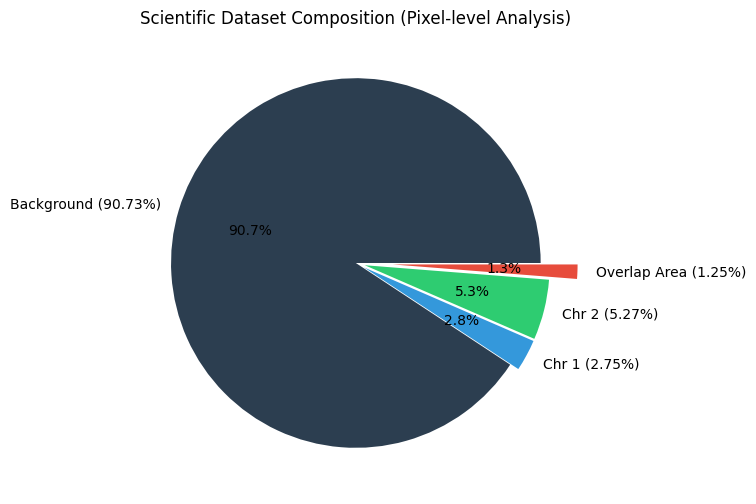

💡 الأوزان المحسوبة (على cuda:0): tensor([ 0.2755,  9.0847,  4.7463, 19.9784], device='cuda:0')


In [3]:
file_path = '/kaggle/input/datasets/jeanpat/overlapping-chromosomes/LowRes_13434_overlapping_pairs.h5'

def run_comprehensive_eda(path):
    with h5py.File(path, 'r') as f:
        dataset = f['dataset_1']
        counts = np.zeros(4)
        # إضافة شريط التقدم tqdm لمتابعة عملية التحليل
        for i in tqdm(range(0, len(dataset), 2000), desc="Analyzing Data"):
            batch = dataset[i:min(i+2000, len(dataset)), :, :, 1]
            vals, b_counts = np.unique(batch, return_counts=True)
            for v, c in zip(vals, b_counts):
                if v < 4: counts[int(v)] += c
    
    classes = ['Background', 'Chr 1', 'Chr 2', 'Overlap Area']
    percentages = (counts / sum(counts)) * 100
    
    plt.figure(figsize=(10, 6))
    plt.pie(percentages, labels=[f'{c} ({p:.2f}%)' for c, p in zip(classes, percentages)], 
            explode=(0, 0.05, 0.05, 0.2), autopct='%1.1f%%', colors=['#2c3e50', '#3498db', '#2ecc71', '#e74c3c'])
    plt.title("Scientific Dataset Composition (Pixel-level Analysis)")
    plt.show()
    
    weights = sum(counts) / (len(counts) * counts)
    # تحويل الأوزان إلى Tensor ونقلها للـ CUDA فوراً لتسريع الـ Loss لاحقاً
    return torch.tensor(weights, dtype=torch.float32).to(device)

final_weights = run_comprehensive_eda(file_path)
print(f"💡 الأوزان المحسوبة (على {final_weights.device}): {final_weights}")

In [4]:
class ChromosomeScientificDataset(Dataset):
    def __init__(self, file_path, indices, transform=None):
        self.file_path = file_path
        self.indices = indices
        self.transform = transform

    def __len__(self): return len(self.indices)

    def __getitem__(self, idx):
        real_idx = self.indices[idx]
        with h5py.File(self.file_path, 'r') as f:
            data = f['dataset_1'][real_idx]
            img, msk = data[:,:,0].astype(np.uint8), data[:,:,1].astype(np.uint8)
            msk[msk > 3] = 0
        if self.transform:
            aug = self.transform(image=img, mask=msk)
            img, msk = aug['image'], aug['mask']
        img = img.float() / 255.0
        if img.ndim == 2: img = img.unsqueeze(0)
        
        # نرسل الـ mask كـ LongTensor لاستخدامه مباشرة في CrossEntropy على الـ GPU
        # ونحتفظ بنسخة One-hot لعملية حساب الـ Dice Loss بدقة
        msk_long = msk.long()
        msk_oh = F.one_hot(msk_long, 4).permute(2, 0, 1).float()
        return img, msk_oh, msk_long

# تقسيم البيانات (70% تدريب، 15% تحقق، 15% اختبار)
total_indices = np.arange(13434)
train_idx, temp_idx = random_split(total_indices, [0.7, 0.3], generator=torch.Generator().manual_seed(42))
val_idx, test_idx = random_split(temp_idx, [0.5, 0.5], generator=torch.Generator().manual_seed(42))

train_trans = A.Compose([A.Resize(128, 128), A.Rotate(limit=30, p=0.5), A.HorizontalFlip(p=0.5), ToTensorV2()])
test_trans = A.Compose([A.Resize(128, 128), ToTensorV2()])

# إضافة pin_memory=True لتسريع النقل إلى CUDA
train_loader = DataLoader(ChromosomeScientificDataset(file_path, train_idx.indices, train_trans), batch_size=32, shuffle=True, pin_memory=True)
val_loader = DataLoader(ChromosomeScientificDataset(file_path, val_idx.indices, test_trans), batch_size=32, pin_memory=True)
test_loader = DataLoader(ChromosomeScientificDataset(file_path, test_idx.indices, test_trans), batch_size=32, pin_memory=True)

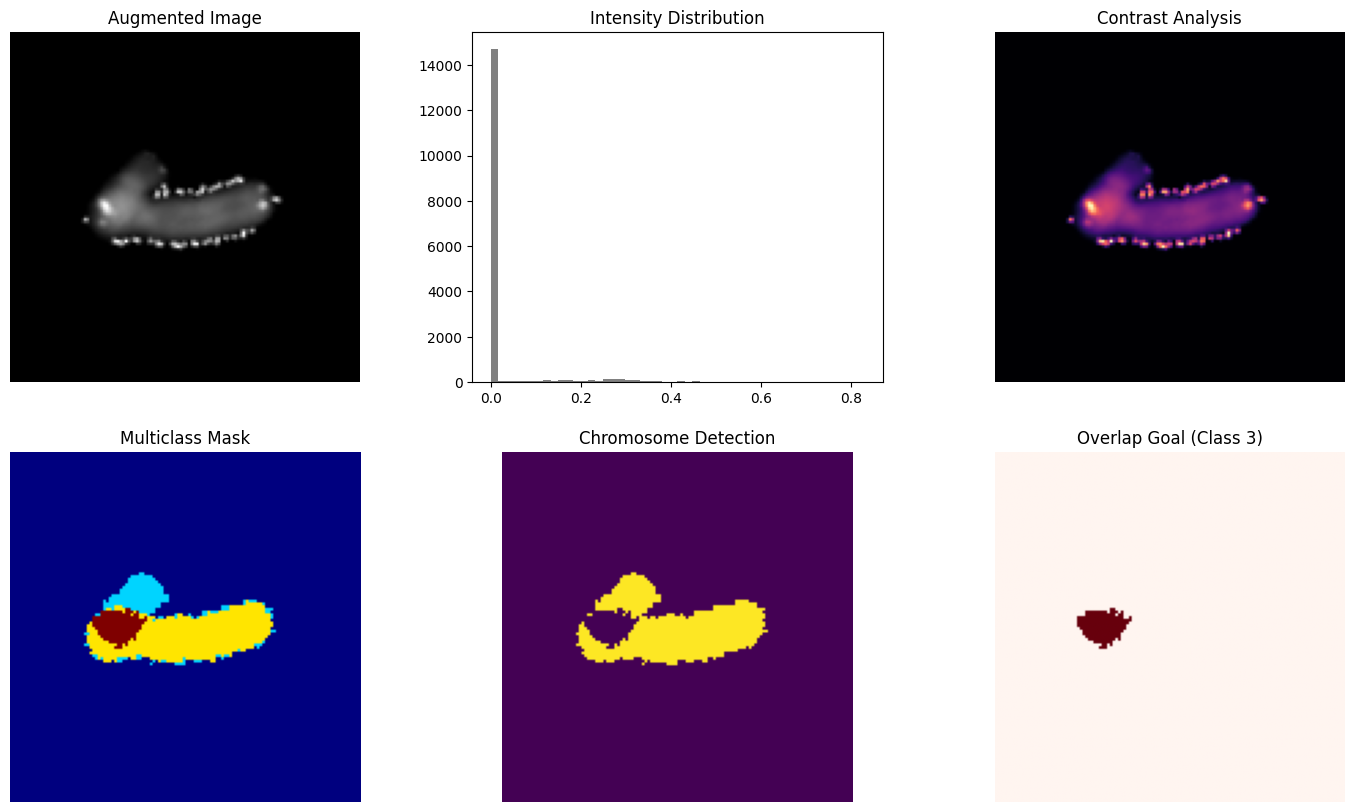

In [6]:
def visualize_detailed_logic(loader):
    # الملحوظة: الـ loader الآن يعيد 3 قيم، نأخذ الصورة والـ mask
    imgs, msks_oh, _ = next(iter(loader))
    img, msk = imgs[0].squeeze().cpu().numpy(), torch.argmax(msks_oh[0], 0).cpu().numpy()
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes[0,0].imshow(img, cmap='gray'); axes[0,0].set_title("Augmented Image")
    axes[0,1].hist(img.flatten(), bins=50, color='gray'); axes[0,1].set_title("Intensity Distribution")
    axes[0,2].imshow(img, cmap='magma'); axes[0,2].set_title("Contrast Analysis")
    
    axes[1,0].imshow(msk, cmap='jet'); axes[1,0].set_title("Multiclass Mask")
    axes[1,1].imshow(np.isin(msk, [1, 2]), cmap='viridis'); axes[1,1].set_title("Chromosome Detection")
    axes[1,2].imshow(msk == 3, cmap='Reds'); axes[1,2].set_title("Overlap Goal (Class 3)")
    
    for ax in axes.flatten(): ax.axis('off')
    axes[0,1].axis('on')
    plt.show()

visualize_detailed_logic(train_loader)

In [8]:
class VGGBlock(nn.Module):
    def __init__(self, in_c, mid_c, out_c):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, mid_c, 3, padding=1), nn.BatchNorm2d(mid_c), nn.ReLU(inplace=True),
            nn.Conv2d(mid_c, out_c, 3, padding=1), nn.BatchNorm2d(out_c), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)

class UNetPlusPlusFinal(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        nb = [32, 64, 128, 256, 512]
        self.pool = nn.MaxPool2d(2, 2)
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        
        self.con0_0 = VGGBlock(1, nb[0], nb[0])
        self.con1_0 = VGGBlock(nb[0], nb[1], nb[1])
        self.con0_1 = VGGBlock(nb[0]+nb[1], nb[0], nb[0])
        self.con2_0 = VGGBlock(nb[1], nb[2], nb[2])
        self.con1_1 = VGGBlock(nb[1]+nb[2], nb[1], nb[1])
        self.con0_2 = VGGBlock(nb[0]*2+nb[1], nb[0], nb[0])
        self.con3_0 = VGGBlock(nb[2], nb[3], nb[3])
        self.con2_1 = VGGBlock(nb[2]+nb[3], nb[2], nb[2])
        self.con1_2 = VGGBlock(nb[1]*2+nb[2], nb[1], nb[1])
        self.con0_3 = VGGBlock(nb[0]*3+nb[1], nb[0], nb[0])
        self.con4_0 = VGGBlock(nb[3], nb[4], nb[4])
        self.con3_1 = VGGBlock(nb[3]+nb[4], nb[3], nb[3])
        self.con2_2 = VGGBlock(nb[2]*2+nb[3], nb[2], nb[2])
        self.con1_3 = VGGBlock(nb[1]*3+nb[2], nb[1], nb[1])
        self.con0_4 = VGGBlock(nb[0]*4+nb[1], nb[0], nb[0])
        self.final = nn.Conv2d(nb[0], num_classes, kernel_size=1)

    def forward(self, x):
        x0_0 = self.con0_0(x)
        x1_0 = self.con1_0(self.pool(x0_0)); x0_1 = self.con0_1(torch.cat([x0_0, self.up(x1_0)], 1))
        x2_0 = self.con2_0(self.pool(x1_0)); x1_1 = self.con1_1(torch.cat([x1_0, self.up(x2_0)], 1)); x0_2 = self.con0_2(torch.cat([x0_0, x0_1, self.up(x1_1)], 1))
        x3_0 = self.con3_0(self.pool(x2_0)); x2_1 = self.con2_1(torch.cat([x2_0, self.up(x3_0)], 1)); x1_2 = self.con1_2(torch.cat([x1_0, x1_1, self.up(x2_1)], 1)); x0_3 = self.con0_3(torch.cat([x0_0, x0_1, x0_2, self.up(x1_2)], 1))
        x4_0 = self.con4_0(self.pool(x3_0)); x3_1 = self.con3_1(torch.cat([x3_0, self.up(x4_0)], 1)); x2_2 = self.con2_2(torch.cat([x2_0, x2_1, self.up(x3_1)], 1)); x1_3 = self.con1_3(torch.cat([x1_0, x1_1, x1_2, self.up(x2_2)], 1)); x0_4 = self.con0_4(torch.cat([x0_0, x0_1, x0_2, x0_3, self.up(x1_3)], 1))
        return self.final(x0_4)

# التأكد من نقل الموديل لـ CUDA
model = UNetPlusPlusFinal().to(device)

Epoch 1/15:   0%|          | 0/294 [00:00<?, ?it/s]

Epoch 2/15:   0%|          | 0/294 [00:00<?, ?it/s]

Epoch 3/15:   0%|          | 0/294 [00:00<?, ?it/s]

Epoch 4/15:   0%|          | 0/294 [00:00<?, ?it/s]

Epoch 5/15:   0%|          | 0/294 [00:00<?, ?it/s]

...

Epoch 11/15:   0%|          | 0/294 [00:00<?, ?it/s]

Epoch 12/15:   0%|          | 0/294 [00:00<?, ?it/s]

Epoch 13/15:   0%|          | 0/294 [00:00<?, ?it/s]

Epoch 14/15:   0%|          | 0/294 [00:00<?, ?it/s]

Epoch 15/15:   0%|          | 0/294 [00:00<?, ?it/s]

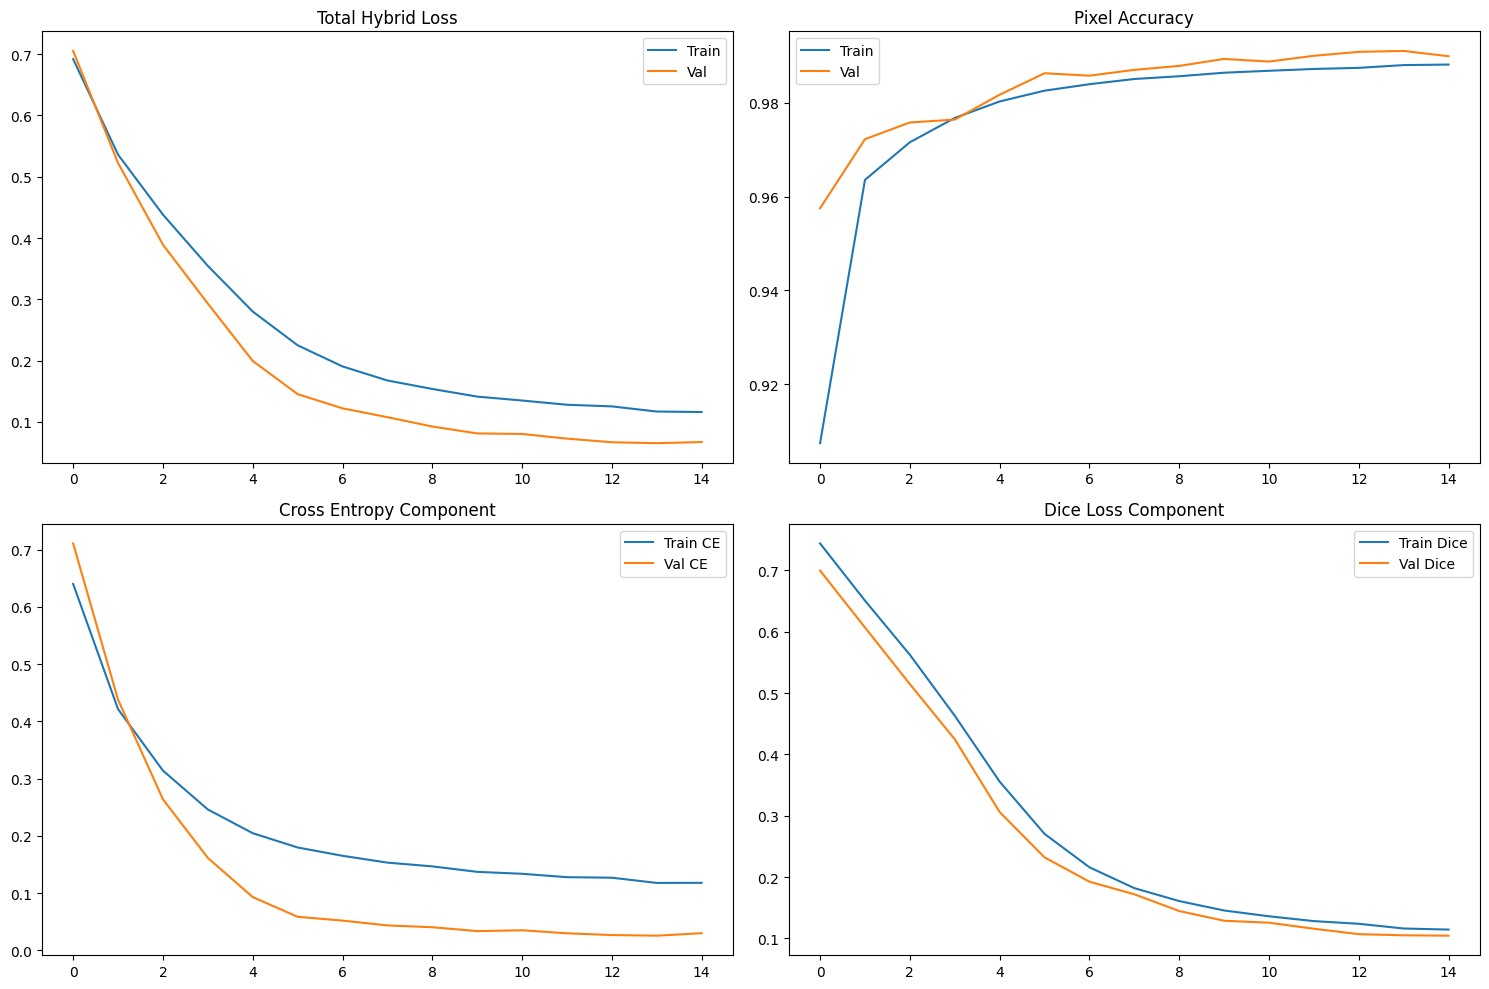

In [9]:
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# توسيع الهيستوري لتخزين كل القيم المنفصلة كما طلبتِ
history = {
    'train_loss': [], 'val_loss': [],
    'train_ce': [], 'val_ce': [],
    'train_dice': [], 'val_dice': [],
    'train_acc': [], 'val_acc': []
}

epochs = 15
for epoch in range(1, epochs + 1):
    model.train()
    train_running_loss, train_running_ce, train_running_dice = 0, 0, 0
    train_correct, train_total = 0, 0
    
    pbar = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}")
    for imgs, msks_oh, msks_long in pbar:
        imgs, msks_oh, msks_long = imgs.to(device), msks_oh.to(device), msks_long.to(device)
        
        optimizer.zero_grad()
        out = model(imgs)
        
        # حساب الـ Hybrid Loss بشكل مفكك
        loss_ce = F.cross_entropy(out, msks_long, weight=final_weights)
        # دالة Dice Loss احترافية
        probs = F.softmax(out, dim=1)
        intersection = (probs * msks_oh).sum(dim=(2, 3))
        union = probs.sum(dim=(2, 3)) + msks_oh.sum(dim=(2, 3))
        loss_dice = 1 - ((2. * intersection + 1e-6) / (union + 1e-6)).mean()
        
        total_loss = 0.5 * loss_ce + 0.5 * loss_dice
        total_loss.backward()
        optimizer.step()
        
        # حساب الدقة (Accuracy)
        preds = torch.argmax(out, 1)
        train_correct += (preds == msks_long).sum().item()
        train_total += msks_long.numel()
        
        train_running_loss += total_loss.item()
        train_running_ce += loss_ce.item()
        train_running_dice += loss_dice.item()
        
        # تحديث شريط التقدم بالدقة واللوس لحظياً
        pbar.set_postfix({
            'Loss': f"{train_running_loss/(pbar.n+1):.4f}",
            'Acc': f"{100*train_correct/train_total:.2f}%"
        })

    # مرحلة التحقق (Validation)
    model.eval()
    val_ce, val_dice, val_acc = 0, 0, 0
    with torch.no_grad():
        for imgs, msks_oh, msks_long in val_loader:
            imgs, msks_oh, msks_long = imgs.to(device), msks_oh.to(device), msks_long.to(device)
            out = model(imgs)
            val_ce += F.cross_entropy(out, msks_long).item()
            
            probs = F.softmax(out, dim=1)
            inter = (probs * msks_oh).sum(dim=(2, 3))
            uni = probs.sum(dim=(2, 3)) + msks_oh.sum(dim=(2, 3))
            val_dice += (1 - ((2. * inter + 1e-6) / (uni + 1e-6)).mean()).item()
            
            preds = torch.argmax(out, 1)
            val_acc += (preds == msks_long).sum().item() / msks_long.numel()

    # تخزين النتائج في الهيستوري
    n_t, n_v = len(train_loader), len(val_loader)
    history['train_loss'].append(train_running_loss/n_t)
    history['train_ce'].append(train_running_ce/n_t)
    history['train_dice'].append(train_running_dice/n_t)
    history['train_acc'].append(train_correct/train_total)
    
    history['val_loss'].append((val_ce+val_dice)/(2*n_v))
    history['val_ce'].append(val_ce/n_v)
    history['val_dice'].append(val_dice/n_v)
    history['val_acc'].append(val_acc/n_v)

# رسم لوحة النتائج الشاملة (Learning Curves)
fig, axs = plt.subplots(2, 2, figsize=(15, 10))
axs[0,0].plot(history['train_loss'], label='Train'); axs[0,0].plot(history['val_loss'], label='Val')
axs[0,0].set_title("Total Hybrid Loss"); axs[0,0].legend()

axs[0,1].plot(history['train_acc'], label='Train'); axs[0,1].plot(history['val_acc'], label='Val')
axs[0,1].set_title("Pixel Accuracy"); axs[0,1].legend()

axs[1,0].plot(history['train_ce'], label='Train CE'); axs[1,0].plot(history['val_ce'], label='Val CE')
axs[1,0].set_title("Cross Entropy Component"); axs[1,0].legend()

axs[1,1].plot(history['train_dice'], label='Train Dice'); axs[1,1].plot(history['val_dice'], label='Val Dice')
axs[1,1].set_title("Dice Loss Component"); axs[1,1].legend()

plt.tight_layout(); plt.show()

Final Testing:   0%|          | 0/63 [00:00<?, ?it/s]

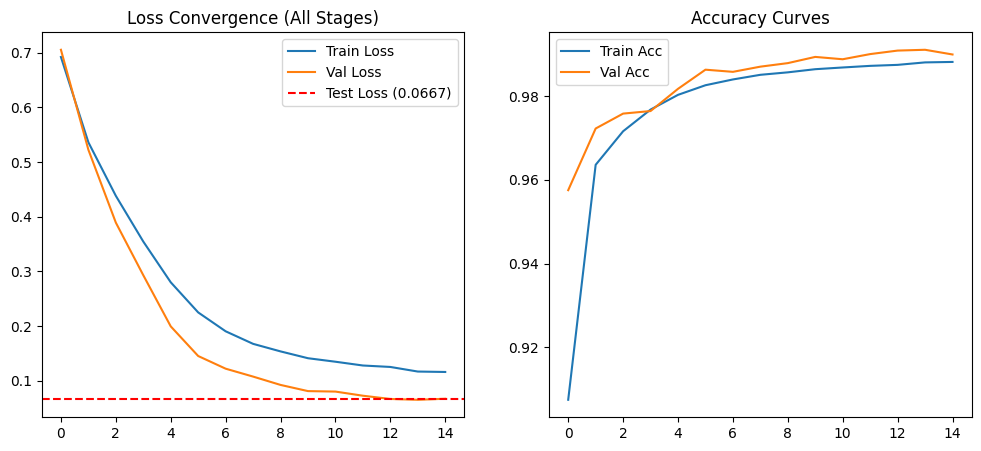


🔢 قيم IoU الرقمية لكل فئة:
   - Background: 0.9939
   - Chr 1: 0.7740
   - Chr 2: 0.9032
   - Overlap Area: 0.8559

📊 تقرير التصنيف النهائي:


,precision,recall,f1-score,support
Background,0.9996,0.9943,0.9970,2.994119e+07
Chr 1,0.8092,0.9468,0.8726,9.111870e+05
Chr 2,0.9601,0.9384,0.9492,1.751971e+06
Overlap Area,0.8779,0.9715,0.9223,4.094080e+05
accuracy,0.9897,0.9897,0.9897,9.897000e-01
macro avg,0.9117,0.9628,0.9353,3.301376e+07
weighted avg,0.9908,0.9897,0.9901,3.301376e+07


In [11]:
from sklearn.metrics import confusion_matrix, classification_report, jaccard_score
def run_final_analytics(model, loader, history):
    model.eval()
    all_p, all_t = [], []
    test_ce, test_dice, test_acc = 0, 0, 0
    
    # حساب IoU بدقة باستخدام jaccard_score
    with torch.no_grad():
        for i, m_oh, m_long in tqdm(loader, desc="Final Testing"):
            i, m_oh, m_long = i.to(device), m_oh.to(device), m_long.to(device)
            out = model(i)
            preds = torch.argmax(out, 1)
            
            all_p.append(preds.cpu().numpy().flatten())
            all_t.append(m_long.cpu().numpy().flatten())
            
            # حساب لوس التيست للإضافة في الرسمة البيانية
            test_ce += F.cross_entropy(out, m_long).item()
            probs = F.softmax(out, dim=1)
            inter = (probs * m_oh).sum(dim=(2, 3))
            uni = probs.sum(dim=(2, 3)) + m_oh.sum(dim=(2, 3))
            test_dice += (1 - ((2. * inter + 1e-6) / (uni + 1e-6)).mean()).item()

    all_p, all_t = np.concatenate(all_p), np.concatenate(all_t)
    
    # 1. رسمة واحدة تجمع الثلاثة (Train, Val, Test) للـ Loss والـ Accuracy
    avg_test_loss = (test_ce + test_dice) / (2 * len(loader))
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.axhline(y=avg_test_loss, color='r', linestyle='--', label=f'Test Loss ({avg_test_loss:.4f})')
    plt.title("Loss Convergence (All Stages)"); plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc')
    plt.plot(history['val_acc'], label='Val Acc')
    plt.title("Accuracy Curves"); plt.legend()
    plt.show()

    # 2. حساب الـ IoU الرقمي لكل كلاس
    iou_values = jaccard_score(all_t, all_p, average=None)
    print("\n🔢 قيم IoU الرقمية لكل فئة:")
    classes = ['Background', 'Chr 1', 'Chr 2', 'Overlap Area']
    for cls, val in zip(classes, iou_values):
        print(f"   - {cls}: {val:.4f}")

    # 3. الجدول الواضح جداً (Classification Report)
    report = classification_report(all_t, all_p, target_names=classes, output_dict=True)
    df_report = pd.DataFrame(report).transpose().round(4)
    
    print("\n📊 تقرير التصنيف النهائي:")
    display(HTML(df_report.to_html(classes='table table-striped table-hover', justify='center')))

run_final_analytics(model, test_loader, history)

In [17]:
from sklearn.metrics import accuracy_score, jaccard_score, classification_report
import seaborn as sns

def run_final_analytics(model, loader, history):
    model.eval()
    all_p, all_t = [], []
    test_ce, test_dice = 0, 0
    
    with torch.no_grad():
        for i, m_oh, m_long in tqdm(loader, desc="Final Evaluation"):
            i, m_oh, m_long = i.to(device), m_oh.to(device), m_long.to(device)
            out = model(i)
            preds = torch.argmax(out, 1)
            
            all_p.append(preds.cpu().numpy().flatten())
            all_t.append(m_long.cpu().numpy().flatten())
            
            # حساب اللوس لمجموعة الاختبار
            test_ce += F.cross_entropy(out, m_long).item()
            probs = F.softmax(out, dim=1)
            inter = (probs * m_oh).sum(dim=(2, 3))
            uni = probs.sum(dim=(2, 3)) + m_oh.sum(dim=(2, 3))
            test_dice += (1 - ((2. * inter + 1e-6) / (uni + 1e-6)).mean()).item()

    all_p = np.concatenate(all_p)
    all_t = np.concatenate(all_t)
    
    # 1. حساب القيم الرقمية النهائية
    avg_test_loss = (test_ce + test_dice) / (2 * len(loader))
    test_acc = accuracy_score(all_t, all_p)
    
    print("-" * 30)
    print(f"🎯 Final Test Loss: {avg_test_loss:.4f}")
    print(f"✅ Final Test Accuracy: {test_acc * 100:.2f}%")
    print("-" * 30)

    # 2. حساب IoU ورسم المخطط البياني (Bar Chart)
    iou_values = jaccard_score(all_t, all_p, average=None)
    classes = ['Background', 'Chr 1', 'Chr 2', 'Overlap Area']
    
    plt.figure(figsize=(10, 6))
    colors = ['#2c3e50', '#3498db', '#2ecc71', '#e74c3c']
    ax = sns.barplot(x=classes, y=iou_values, palette=colors)
    
    # إضافة الأرقام فوق الأعمدة
    for p in ax.patches:
        ax.annotate(format(p.get_height(), '.4f'), 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', xytext=(0, 9), textcoords='offset points',
                    fontsize=11, fontweight='bold')
    
    plt.title('Test Set: IoU Scores per Class', fontsize=14)
    plt.ylabel('IoU Value')
    plt.ylim(0, 1.1)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.show()

    # 3. عرض جدول التصنيف (Classification Report)
    report = classification_report(all_t, all_p, target_names=classes, output_dict=True)
    df_report = pd.DataFrame(report).transpose().round(4)
    
    print("\n📊 تقرير التصنيف النهائي (Classification Report):")
    display(HTML(df_report.to_html(classes='table table-striped table-hover', justify='center')))

# تشغيل التحليل

Final Evaluation:   0%|          | 0/63 [00:00<?, ?it/s]

------------------------------
🎯 Final Test Loss: 0.0667
✅ Final Test Accuracy: 98.97%
------------------------------


/tmp/ipykernel_55/508515661.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=classes, y=iou_values, palette=colors)


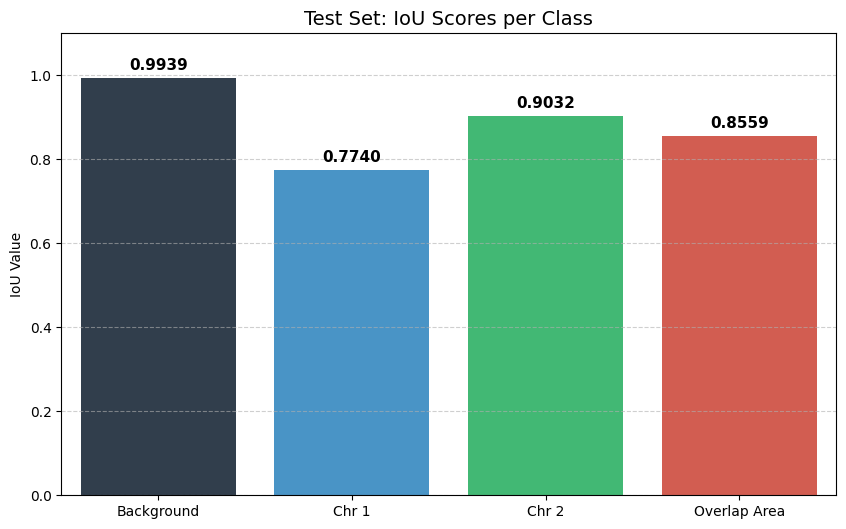


📊 تقرير التصنيف النهائي (Classification Report):


,precision,recall,f1-score,support
Background,0.9996,0.9943,0.9970,2.994119e+07
Chr 1,0.8092,0.9468,0.8726,9.111870e+05
Chr 2,0.9601,0.9384,0.9492,1.751971e+06
Overlap Area,0.8779,0.9715,0.9223,4.094080e+05
accuracy,0.9897,0.9897,0.9897,9.897000e-01
macro avg,0.9117,0.9628,0.9353,3.301376e+07
weighted avg,0.9908,0.9897,0.9901,3.301376e+07


In [18]:
run_final_analytics(model, test_loader, history)